R-squared: 0.9518
Fitted Parameters:
Carrying Capacity (L): 20.89
Growth Rate (k): 0.20
Midpoint (x0): -0.57


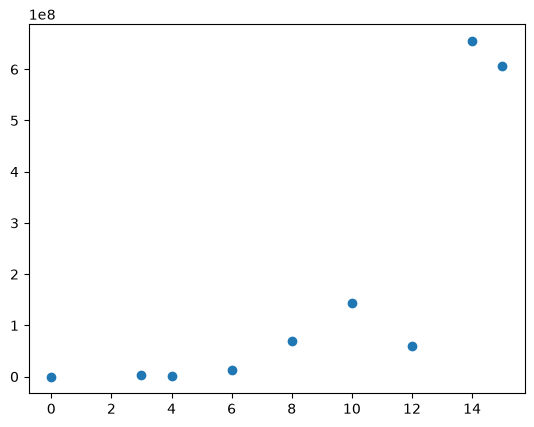

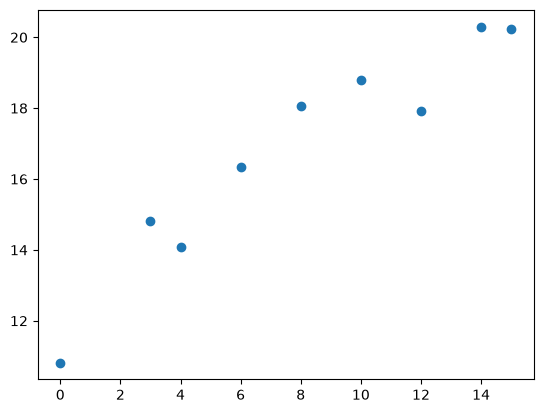

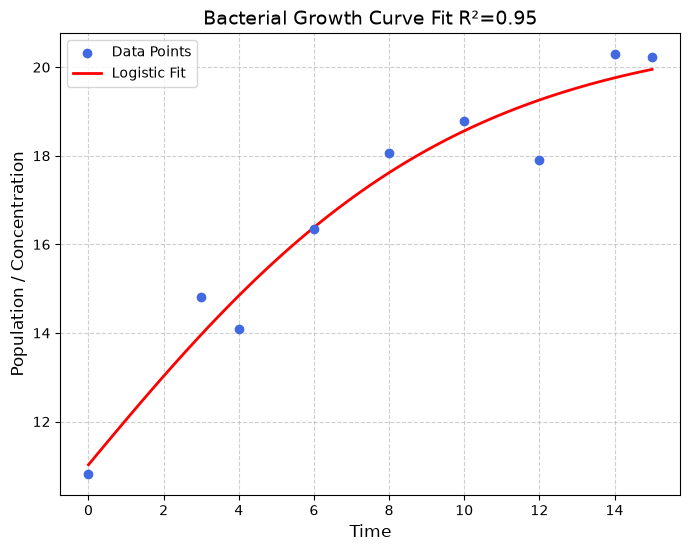

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Read data, and compute the date as days from t=0
data = pd.read_excel("/home/kb/MyStuff/Stuff/UToronto/NiMBLE Work/Projects/Log Growth Curve/data.xlsx")
data["Date"] = pd.to_datetime(data["Date"])
start = data["Date"].values[0]
data["Date"] = data["Date"] - start
data["Date"] = data["Date"].astype(np.int64) / (1e6 * 3600 * 24)
plt.scatter(data["Date"], data["Number"])
plt.figure()
plt.scatter(data["Date"], data["LN(Number)"])

# Actual fitting starts here:
t = data["Date"].values
log_y = data["LN(Number)"].values

def logistic_model(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# 3. Fit the model to the data
# We provide 'p0' as an initial guess to help the solver find the curve
initial_guesses = [21, 0.5, 7] 
params, covariance = curve_fit(logistic_model, t, log_y, p0=initial_guesses)

L_fit, k_fit, x0_fit = params
 # 1. Calculate the predicted y values using the fitted parameters
y_fit = logistic_model(t, *params)

# 2. Calculate Sum of Squares
ss_res = np.sum((log_y - y_fit) ** 2)          # Residual sum of squares
ss_tot = np.sum((log_y - np.mean(log_y)) ** 2) # Total sum of squares

# 3. Calculate R2
r2 = 1 - (ss_res / ss_tot)

print(f"R-squared: {r2:.4f}")
print(
    f"Fitted Parameters:\n"
    f"Carrying Capacity (L): {L_fit:.2f}\n"
    f"Growth Rate (k): {k_fit:.2f}\n"
    f"Midpoint (x0): {x0_fit:.2f}"
)

# 4. Generate points for a smooth curve
x_smooth = np.linspace(0, 15, 100)
y_smooth = logistic_model(x_smooth, *params)

# 5. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(t, log_y, color='royalblue', label='Data Points', zorder=3)
plt.plot(x_smooth, y_smooth, color='red', linewidth=2, label='Logistic Fit')

plt.title(f'Bacterial Growth Curve Fit R²={r2:.2f}', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Population / Concentration', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()